In [23]:
import os
import shutil
import random

# --- CONFIGURATION ---
# L'ajout du 'r' devant les chemins empêche l'erreur unicode sous Windows
dossiers_sources = [
    r'C:\Users\540084\Downloads\clé-20260516T224456Z-3-001', 
    r'C:\Users\540084\Downloads\train_1-20260517T044500Z-3-001', 
    r'C:\Users\540084\Downloads\remote-20260516T224500Z-3-001', 
    r'C:\Users\540084\Downloads\smartphone-20260516T224503Z-3-001',
    r'C:\Users\540084\Downloads\train_2-20260517T044503Z-3-001',
    r'C:\Users\540084\Downloads\keys3-20260517T044452Z-3-001',
    r'C:\Users\540084\Downloads\train_key-20260517T044506Z-3-001',
    r'C:\Users\540084\Downloads\SmartPhone2-20260517T044456Z-3-001'
]

# Dossier principal où sera créé le nouveau dataset
dossier_destination = 'dataset_final'

# Ratio de séparation (0.8 = 80% train, 20% val)
ratio_train = 0.8
# ---------------------

# 1. Création de l'arborescence de destination
dossiers_a_creer = [
    os.path.join(dossier_destination, 'images', 'train'),
    os.path.join(dossier_destination, 'images', 'val'),
    os.path.join(dossier_destination, 'labels', 'train'),
    os.path.join(dossier_destination, 'labels', 'val')
]

for dossier in dossiers_a_creer:
    os.makedirs(dossier, exist_ok=True)

print("Création des dossiers de destination terminée.")

# 2. Traitement de chaque dossier source
for dossier_source in dossiers_sources:
    chemin_images = os.path.join(dossier_source, 'images')
    chemin_labels = os.path.join(dossier_source, 'labels corrigé')
    
    # Vérification que les sous-dossiers existent
    if not os.path.exists(chemin_images) or not os.path.exists(chemin_labels):
        print(f"⚠️ Attention : Le dossier {dossier_source} ne contient pas 'images' ou 'labels corrigé'. Ignoré.")
        continue

    # Récupérer la liste des images
    images = [f for f in os.listdir(chemin_images) if os.path.isfile(os.path.join(chemin_images, f))]
    
    # Mélanger les images aléatoirement pour une distribution juste
    random.shuffle(images)
    
    # Calculer l'index de coupure pour le ratio 80/20
    split_index = int(len(images) * ratio_train)
    
    images_train = images[:split_index]
    images_val = images[split_index:]
    
    # Fonction locale pour gérer la copie
    def copier_fichiers(liste_images, type_split):
        dest_img = os.path.join(dossier_destination, 'images', type_split)
        dest_lbl = os.path.join(dossier_destination, 'labels', type_split)
        
        for nom_image in liste_images:
            # --- Copie de l'image ---
            src_img_path = os.path.join(chemin_images, nom_image)
            shutil.copy(src_img_path, os.path.join(dest_img, nom_image))
            
            # --- Recherche et copie du label correspondant ---
            # On extrait le nom sans l'extension (ex: "photo1.jpg" -> "photo1")
            nom_base = os.path.splitext(nom_image)[0]
            label_trouve = False
            
            # On cherche dans le dossier labels un fichier qui commence par ce nom de base
            for nom_label in os.listdir(chemin_labels):
                if nom_label.startswith(nom_base + "."):
                    src_lbl_path = os.path.join(chemin_labels, nom_label)
                    shutil.copy(src_lbl_path, os.path.join(dest_lbl, nom_label))
                    label_trouve = True
                    break
            
            if not label_trouve:
                print(f"⚠️ Aucun label trouvé pour l'image : {nom_image}")

    # Exécution de la copie pour Train et Val
    copier_fichiers(images_train, 'train')
    copier_fichiers(images_val, 'val')
    
    print(f"✅ Dossier '{dossier_source}' traité : {len(images_train)} images dans train, {len(images_val)} images dans val.")

print("\n🚀 Séparation du dataset terminée avec succès !")

Création des dossiers de destination terminée.
✅ Dossier 'C:\Users\540084\Downloads\clé-20260516T224456Z-3-001' traité : 864 images dans train, 216 images dans val.
✅ Dossier 'C:\Users\540084\Downloads\train_1-20260517T044500Z-3-001' traité : 24 images dans train, 7 images dans val.
✅ Dossier 'C:\Users\540084\Downloads\remote-20260516T224500Z-3-001' traité : 800 images dans train, 200 images dans val.
✅ Dossier 'C:\Users\540084\Downloads\smartphone-20260516T224503Z-3-001' traité : 712 images dans train, 178 images dans val.
✅ Dossier 'C:\Users\540084\Downloads\train_2-20260517T044503Z-3-001' traité : 34 images dans train, 9 images dans val.
✅ Dossier 'C:\Users\540084\Downloads\keys3-20260517T044452Z-3-001' traité : 188 images dans train, 48 images dans val.
✅ Dossier 'C:\Users\540084\Downloads\train_key-20260517T044506Z-3-001' traité : 1081 images dans train, 271 images dans val.
✅ Dossier 'C:\Users\540084\Downloads\SmartPhone2-20260517T044456Z-3-001' traité : 260 images dans train, 65

In [24]:
import torch
print("Carte graphique trouvée :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nom de la carte :", torch.cuda.get_device_name(0))

Carte graphique trouvée : True
Nom de la carte : NVIDIA GeForce RTX 4060 Laptop GPU


In [25]:
import ultralytics
ultralytics.checks()

# 1. Création du fichier YAML avec vos chemins Windows
yaml_content = """
path: C:/Users/540084/Downloads

train: images/train
val: images/val

# Nombre total de classes
nc: 3

# Noms des classes. L'ordre est vital : 0=remote, 1=keys, 2=smartphone
names: ['remote', 'keys', 'smartphone']
"""

# Le fichier sera sauvegardé directement dans votre dossier Téléchargements
chemin_fichier = 'C:/Users/540084/Downloads/dataset_objets.yaml'

with open(chemin_fichier, 'w', encoding='utf-8') as f:
    f.write(yaml_content)

print(f"✅ Fichier YAML créé avec succès ici : {chemin_fichier}")

# ---------------------------------------------------------
# 2. Lancement de l'entraînement
# ---------------------------------------------------------
from ultralytics import YOLO

# Charger le modèle
model = YOLO('yolov26n.pt') 

print("🚀 Démarrage de l'entraînement en local...")
results = model.train(
    data='C:/Users/540084/Downloads/dataset_objets.yaml', # Chemin vers le YAML
    epochs=50,             
    imgsz=640,             
    batch=8,               # Gardez 8 pour préserver la mémoire (RAM) de votre PC
    device=0,            
    project='C:/Users/540084/Downloads/YOLO_Resultats', # Dossier de sauvegarde
    name='modele_objets_personnels',                 
    mosaic=1.0,            
    mixup=0.2,             
    degrees=15.0           
)

Ultralytics 8.4.51  Python-3.10.20 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (20 CPUs, 31.7 GB RAM, 575.3/953.0 GB disk)
✅ Fichier YAML créé avec succès ici : C:/Users/540084/Downloads/dataset_objets.yaml
🚀 Démarrage de l'entraînement en local...
Ultralytics 8.4.51  Python-3.10.20 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/540084/Downloads/dataset_objets.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0

In [22]:
import cv2
from ultralytics import YOLO

# 1. Charger VOTRE modèle entraîné
chemin_modele = 'C:/Users/540084/Downloads/YOLO_Resultats/modele_objets_personnels-4/weights/best.pt'
model = YOLO(chemin_modele)

# 2. Allumer la webcam (Le chiffre 0 correspond à la webcam par défaut de l'ordinateur)
cap = cv2.VideoCapture(0)

print("🎥 Webcam activée ! Appuyez sur la touche 'q' de votre clavier pour quitter.")

while cap.isOpened():
    # Lire l'image de la webcam image par image
    success, frame = cap.read()
    
    if success:
        # 3. Demander à YOLO d'analyser l'image
        # conf=0.5 signifie "Ne me montre que les détections dont tu es sûr à plus de 50%"
        results = model.predict(frame, conf=0.5, verbose=False)
        
        # 4. Dessiner les boîtes de détection sur l'image
        image_annotee = results[0].plot()
        
        # 5. Afficher la vidéo
        cv2.imshow("Détection en direct - YOLO", image_annotee)
        
        # 6. Arrêter la vidéo si on appuie sur la touche 'q'
        if cv2.waitKey(1) & 0xFF == ord("q"):
            print("🛑 Arrêt de la webcam.")
            break
    else:
        break

# Tout fermer proprement à la fin
cap.release()
cv2.destroyAllWindows()

🎥 Webcam activée ! Appuyez sur la touche 'q' de votre clavier pour quitter.
🛑 Arrêt de la webcam.


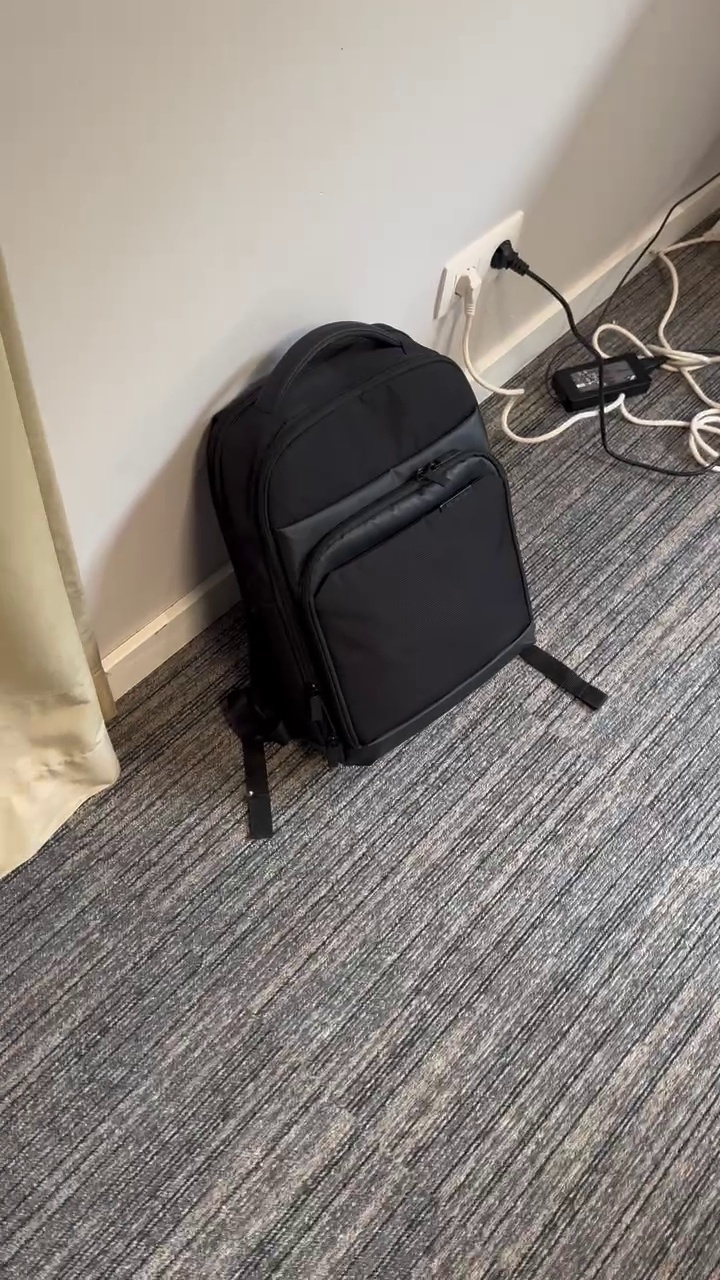

✅ Lecture terminée !


In [19]:
import cv2
from ultralytics import YOLO
from IPython.display import display, Image, clear_output

# 1. Charger VOTRE modèle entraîné
chemin_modele = 'C:/Users/540084/Downloads/YOLO_Resultats/modele_objets_personnels-4/weights/best.pt'
model = YOLO(chemin_modele)

# 2. Charger votre vidéo (Remplacez par le nom exact de votre fichier)
# Note : Vous pouvez aussi mettre 0 à la place du chemin pour utiliser la webcam !
chemin_video = 'C:/Users/540084/Downloads/IMG_5069.MOV'
cap = cv2.VideoCapture(chemin_video)

print("🎬 Démarrage de la vidéo intégrée...")

try:
    while cap.isOpened():
        success, frame = cap.read()
        
        # Si la vidéo est terminée (ou introuvable), on arrête
        if not success:
            break
            
        # 3. Demander à YOLO d'analyser l'image
        results = model.predict(frame, conf=0.5, verbose=False)
        
        # 4. Dessiner les boîtes de détection sur l'image
        image_annotee = results[0].plot()
        
        # 5. Astuce Jupyter : Convertir l'image en format affichable
        _, buffer = cv2.imencode('.jpg', image_annotee)
        
        # 6. Effacer l'image précédente et afficher la nouvelle (crée l'effet vidéo)
        clear_output(wait=True)
        display(Image(data=buffer.tobytes()))

except KeyboardInterrupt:
    # Permet d'arrêter proprement si vous cliquez sur le bouton "Stop" (■) de Jupyter
    print("🛑 Arrêt manuel de la vidéo.")

finally:
    # Toujours libérer la mémoire à la fin
    cap.release()
    print("✅ Lecture terminée !")